# Lab 1: Decision-Oriented EDA — F1 Top 10 Prediction

**Team:** feligna  
**Objective:** Predict whether a driver finishes in the Top 10 of an F1 race (2022-2024 seasons)  
**Date:** March 16, 2026

> This notebook follows a decision-oriented structure: every analysis starts with a question and ends with a decision. We use temporal splits to avoid leakage and document all data quality findings.

In [1]:
# ── Reproducibility Header ────────────────────────────────────────────
# Every notebook in IIT414W starts here. Do not skip this block.

import sys, random
import numpy as np
import warnings

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')

Python  : 3.14.2
NumPy   : 2.4.3
Seed    : 414


In [2]:
# -- Dependency Guard --------------------------------------------------
import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'requests': 'requests',
    'fastf1': 'fastf1',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# -- Library Imports --------------------------------------------------
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import fastf1

# -- FastF1 Cache (same pattern as class notebooks) -------------------
cache_path = os.path.join(os.getcwd(), 'data', 'fastf1_cache')
os.makedirs(cache_path, exist_ok=True)
fastf1.Cache.enable_cache(cache_path)

# -- Plot defaults ----------------------------------------------------
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print(f'pandas  : {pd.__version__}')
print(f'fastf1  : {fastf1.__version__}')
print(f'cache   : {cache_path}')
print('Libraries loaded successfully ✓')

All required packages already installed ✓
pandas  : 2.3.3
fastf1  : 3.8.1
cache   : c:\Users\feliv\Documents\GitHub\iit414w-lab01-feligna\data\fastf1_cache
Libraries loaded successfully ✓


## 1. Data Ingestion: Jolpica API Pipeline

Query F1 race results from 2022-2024 using the Jolpica API. Include rate limiting and retry logic to handle API load.

In [3]:
# ── Jolpica API: Season Results Pipeline (with rate limiting) ─────

def get_season_results(year: int, max_retries: int = 3) -> pd.DataFrame:
    """
    Pull all race results for a given season from the Jolpica API.
    Includes pagination, rate limiting, and retry with exponential backoff.
    """
    all_races = []
    offset = 0
    limit = 100

    while True:
        url = f"https://api.jolpi.ca/ergast/f1/{year}/results.json?limit={limit}&offset={offset}"

        for attempt in range(max_retries):
            try:
                time.sleep(1.0)  # Rate limit: 1 second between requests
                response = requests.get(url, timeout=30)
                response.raise_for_status()
                break
            except (requests.exceptions.RequestException) as e:
                wait = 2 ** attempt * 2  # Exponential backoff: 2s, 4s, 8s
                print(f"Attempt {attempt + 1}/{max_retries} failed for {year} (offset {offset}): {e}")
                if attempt < max_retries - 1:
                    print(f"      Retrying in {wait}s...")
                    time.sleep(wait)
                else:
                    raise RuntimeError(f"API failed after {max_retries} attempts for {year}") from e

        data = response.json()['MRData']
        total = int(data['total'])
        races = data['RaceTable']['Races']
        all_races.extend(races)
        offset += limit
        if offset >= total:
            break

    rows = []
    for race in all_races:
        for result in race['Results']:
            rows.append({
                'season': int(race['season']),
                'round': int(race['round']),
                'race_date': race['date'],
                'race_name': race['raceName'],
                'circuit_id': race['Circuit']['circuitId'],
                'circuit_name': race['Circuit']['circuitName'],
                'country': race['Circuit']['Location']['country'],
                'driver_id': result['Driver']['driverId'],
                'driver_code': result['Driver']['code'],
                'first_name': result['Driver']['givenName'],
                'last_name': result['Driver']['familyName'],
                'dob': result['Driver'].get('dateOfBirth', np.nan),
                'nationality': result['Driver'].get('nationality', np.nan),
                'constructor': result['Constructor']['name'],
                'grid': int(result['grid']) if result['grid'] != '0' else np.nan,
                'position_text': result['position'],
                'position': int(result['position']) if result['position'].isdigit() else np.nan,
                'points': float(result['points']),
                'laps': int(result['laps']) if result['laps'] else 0,
                'status': result['status'],
            })

    df = pd.DataFrame(rows)
    df['race_date'] = pd.to_datetime(df['race_date'])
    return df

# Load data for 2022, 2023, 2024
print("Loading F1 race results from Jolpica API...")
results_list = []
for year in [2022, 2023, 2024]:
    print(f"\n  → {year}...")
    df_year = get_season_results(year)
    results_list.append(df_year)
    print(f"     Loaded {len(df_year)} results across {df_year['round'].max()} rounds")

results = pd.concat(results_list, ignore_index=True)
print(f"\n Total: {len(results)} race results across 3 seasons")
print(f"Date range: {results['race_date'].min().date()} to {results['race_date'].max().date()}")

Loading F1 race results from Jolpica API...

  → 2022...
     Loaded 440 results across 22 rounds

  → 2023...
     Loaded 440 results across 22 rounds

  → 2024...
     Loaded 479 results across 24 rounds

 Total: 1359 race results across 3 seasons
Date range: 2022-03-20 to 2024-12-08


In [4]:
# ── Create derived features ────────────────────────────────────────
results['dob'] = pd.to_datetime(results['dob'], errors='coerce')
results['age_at_race'] = results['season'] - results['dob'].dt.year

# Binary target: Top 10 finish
results['top_10'] = (results['position'] <= 10).astype(int)

# DNF flag: status != 'Finished' and not a '+X Lap(s)' classification
results['dnf'] = (~results['status'].str.contains('Finished|\\+', regex=True, na=False)).astype(int)

# Constructor tier (classify by total season points 2022-2024)
constructor_total = results.groupby('constructor')['points'].sum().sort_values(ascending=False)
top_4_constructors = constructor_total.head(4).index.tolist()
results['constructor_tier'] = results['constructor'].apply(
    lambda x: 'Top 4' if x in top_4_constructors else 'Other'
)

# Grid group (F1 has max 20 drivers per race)
results['grid_group'] = pd.cut(
    results['grid'],
    bins=[0, 10, 20],
    labels=['Grid 1-10', 'Grid 11-20'],
    right=True
)

print(f"\nDataset shape: {results.shape}")
print(f"Seasons: {sorted(results['season'].unique())}")
print(f"DNF rate: {results['dnf'].mean():.1%}")
print(f"Top 10 rate: {results['top_10'].mean():.1%}")
print(f"\nFirst 5 rows:")
print(results[['season', 'race_name', 'driver_code', 'constructor', 'grid', 'position', 'top_10', 'dnf']].head())


Dataset shape: (1359, 25)
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
DNF rate: 29.6%
Top 10 rate: 50.0%

First 5 rows:
   season           race_name driver_code   constructor  grid  position  \
0    2022  Bahrain Grand Prix         LEC       Ferrari   1.0         1   
1    2022  Bahrain Grand Prix         SAI       Ferrari   3.0         2   
2    2022  Bahrain Grand Prix         HAM      Mercedes   5.0         3   
3    2022  Bahrain Grand Prix         RUS      Mercedes   9.0         4   
4    2022  Bahrain Grand Prix         MAG  Haas F1 Team   7.0         5   

   top_10  dnf  
0       1    0  
1       1    0  
2       1    0  
3       1    0  
4       1    0  


## 2. Data Quality Audit (Requirement 3.7)

We examine missing values, data types, and temporal coverage before proceeding to analysis.

In [5]:
# ── Missing values analysis ────────────────────────────────────────
print("=" * 80)
print("MISSING VALUES BY COLUMN")
print("=" * 80)

missing_analysis = pd.DataFrame({
    'Column': results.columns,
    'Missing_Count': results.isnull().sum(),
    'Missing_Pct': (results.isnull().sum() / len(results) * 100).round(1),
    'Data_Type': results.dtypes,
})
missing_analysis = missing_analysis[missing_analysis['Missing_Count'] > 0].sort_values('Missing_Pct', ascending=False)

if len(missing_analysis) == 0:
    print("No missing values found in this extraction.")
else:
    print(missing_analysis.to_string(index=False))

print("\n" + "=" * 80)
print("MISSING-VALUE CLASSIFICATION (evidence-based)")
print("=" * 80)

grid_missing_count = int(results['grid'].isna().sum())
grid_missing_pct = (grid_missing_count / len(results) * 100)

print(f"\n1. GRID (Missing: {grid_missing_pct:.1f}%)")
print("   → Classification: Structural missingness (MAR)")
print("   → Reason: API reports grid='0' for pit-lane starts; in this notebook it is converted to NaN")
print("   → Decision: For the simple baseline (grid <= 10), drop rows with grid NaN")

if 'dob' in results.columns:
    dob_missing = int(results['dob'].isna().sum())
    print(f"\n2. DATE OF BIRTH (Missing: {dob_missing / len(results) * 100:.1f}%)")
    if dob_missing == 0:
        print("   → Classification: No missingness in this extraction")
        print("   → Decision: Keep as-is")
    else:
        print("   → Classification: Likely MCAR (metadata gaps)")
        print("   → Decision: Keep; age is optional for baseline")

if 'position' in results.columns:
    pos_missing = int(results['position'].isna().sum())
    print(f"\n3. POSITION (Missing: {pos_missing / len(results) * 100:.1f}%)")
    if pos_missing == 0:
        print("   → Classification: No missingness in this extraction")
        print("   → Decision: Keep as-is")
    else:
        print("   → Classification: Outcome-dependent missingness (MNAR)")
        print("   → Decision: Fill with 999 and map to top_10=0")

# Handle missing values for modeling dataset
results_clean = results.copy()
if results_clean['position'].isna().any():
    results_clean['position'] = results_clean['position'].fillna(999)
results_clean['top_10'] = (results_clean['position'] <= 10).astype(int)

rows_before = len(results_clean)
results_clean = results_clean[results_clean['grid'].notna()]  # keep only rows usable by grid baseline
rows_after = len(results_clean)

print(f"\nAfter cleaning: {rows_after} rows remain")
print(f"Rows removed due to grid NaN: {rows_before - rows_after}")
print(f"Grid coverage in modeling set: {(results_clean['grid'].notna().mean() * 100):.1f}%")

MISSING VALUES BY COLUMN
    Column  Missing_Count  Missing_Pct Data_Type
      grid             15          1.1   float64
grid_group             15          1.1  category

MISSING-VALUE CLASSIFICATION (evidence-based)

1. GRID (Missing: 1.1%)
   → Classification: Structural missingness (MAR)
   → Reason: API reports grid='0' for pit-lane starts; in this notebook it is converted to NaN
   → Decision: For the simple baseline (grid <= 10), drop rows with grid NaN

2. DATE OF BIRTH (Missing: 0.0%)
   → Classification: No missingness in this extraction
   → Decision: Keep as-is

3. POSITION (Missing: 0.0%)
   → Classification: No missingness in this extraction
   → Decision: Keep as-is

After cleaning: 1344 rows remain
Rows removed due to grid NaN: 15
Grid coverage in modeling set: 100.0%


### 2.1 Outlier Audit (Requirement 3.7 extension)

To complete the data quality audit, we check numeric outliers using the IQR rule and document handling decisions for at least 3 columns.

In [6]:
# ── Outlier audit with IQR rule (numeric columns) ───────────────────
numeric_cols_for_outliers = ['grid', 'age_at_race', 'laps']

outlier_rows = []
for col in numeric_cols_for_outliers:
    s = results[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask_out = (results[col] < lower) | (results[col] > upper)
    n_out = int(mask_out.sum())
    pct_out = (n_out / len(results)) * 100
    
    # Data-quality decision by variable meaning
    if col == 'grid':
        decision = 'Keep (domain-bounded 1-20; outliers mainly from missing conversion already handled)'
    elif col == 'age_at_race':
        decision = 'Keep + monitor (possible rookies/veterans; no hard clipping in baseline)'
    else:
        decision = 'Keep (race/circuit effects; not used in baseline rule)'
    
    outlier_rows.append({
        'column': col,
        'q1': round(float(q1), 2),
        'q3': round(float(q3), 2),
        'iqr': round(float(iqr), 2),
        'lower_bound': round(float(lower), 2),
        'upper_bound': round(float(upper), 2),
        'outlier_count': n_out,
        'outlier_pct': round(float(pct_out), 2),
        'decision': decision,
    })

outlier_table = pd.DataFrame(outlier_rows)
print('=' * 80)
print('OUTLIER AUDIT (IQR RULE)')
print('=' * 80)
print(outlier_table.to_string(index=False))

OUTLIER AUDIT (IQR RULE)
     column   q1   q3  iqr  lower_bound  upper_bound  outlier_count  outlier_pct                                                                            decision
       grid  5.0 15.0 10.0        -10.0         30.0              0         0.00 Keep (domain-bounded 1-20; outliers mainly from missing conversion already handled)
age_at_race 25.0 33.0  8.0         13.0         45.0              0         0.00            Keep + monitor (possible rookies/veterans; no hard clipping in baseline)
       laps 51.0 69.0 18.0         24.0         96.0             94         6.92                              Keep (race/circuit effects; not used in baseline rule)


### 2.2 Candidate Feature Correlation Screen (Requirement 3.4)

We evaluate at least 5 candidate features with appropriate association measures and direction/magnitude interpretation.

Candidate features screened here: `grid`, `age_at_race`, `round`, `constructor_tier`, `dnf` (diagnostic only; post-race leakage).

In [7]:
# ── Explicit feature screening: 5 candidates ─────────────────────────
from scipy.stats import spearmanr, chi2_contingency

screen_df = results_clean.copy()

rows = []

# 1) grid (numeric, ordinal)
r_grid, p_grid = spearmanr(screen_df['grid'], screen_df['top_10'])
rows.append({
    'feature': 'grid',
    'type': 'numeric',
    'measure': 'Spearman r',
    'value': round(float(r_grid), 3),
    'p_value': f"{p_grid:.2e}",
    'baseline_use': 'YES (pre-race)',
})

# 2) age_at_race (numeric)
age_data = screen_df[['age_at_race', 'top_10']].dropna()
if len(age_data) > 0:
    r_age, p_age = spearmanr(age_data['age_at_race'], age_data['top_10'])
else:
    r_age, p_age = (np.nan, np.nan)
rows.append({
    'feature': 'age_at_race',
    'type': 'numeric',
    'measure': 'Spearman r',
    'value': round(float(r_age), 3) if pd.notna(r_age) else np.nan,
    'p_value': f"{p_age:.2e}" if pd.notna(p_age) else 'NA',
    'baseline_use': 'NO (weak/secondary)',
})

# 3) round (numeric, temporal index inside season)
r_round, p_round = spearmanr(screen_df['round'], screen_df['top_10'])
rows.append({
    'feature': 'round',
    'type': 'numeric',
    'measure': 'Spearman r',
    'value': round(float(r_round), 3),
    'p_value': f"{p_round:.2e}",
    'baseline_use': 'NO (small signal)',
})

# 4) constructor_tier (categorical)
ct_tier = pd.crosstab(screen_df['constructor_tier'], screen_df['top_10'])
chi2_tier, p_tier, _, _ = chi2_contingency(ct_tier)
rows.append({
    'feature': 'constructor_tier',
    'type': 'categorical',
    'measure': 'Chi-square',
    'value': round(float(chi2_tier), 3),
    'p_value': f"{p_tier:.2e}",
    'baseline_use': 'MAYBE (good for stretch)',
})

# 5) dnf (categorical, leakage variable)
ct_dnf = pd.crosstab(screen_df['dnf'], screen_df['top_10'])
chi2_dnf, p_dnf, _, _ = chi2_contingency(ct_dnf)
rows.append({
    'feature': 'dnf',
    'type': 'categorical',
    'measure': 'Chi-square',
    'value': round(float(chi2_dnf), 3),
    'p_value': f"{p_dnf:.2e}",
    'baseline_use': 'NO (post-race leakage)',
})

feature_screen = pd.DataFrame(rows)

print('=' * 80)
print('EXPLICIT CORRELATION/ASSOCIATION SCREEN (5 CANDIDATE FEATURES)')
print('=' * 80)
print(feature_screen.to_string(index=False))

EXPLICIT CORRELATION/ASSOCIATION SCREEN (5 CANDIDATE FEATURES)
         feature        type    measure   value   p_value             baseline_use
            grid     numeric Spearman r  -0.571 2.73e-117           YES (pre-race)
     age_at_race     numeric Spearman r   0.056  4.09e-02      NO (weak/secondary)
           round     numeric Spearman r   0.002  9.50e-01        NO (small signal)
constructor_tier categorical Chi-square 359.664  3.33e-80 MAYBE (good for stretch)
             dnf categorical Chi-square 477.721 6.69e-106   NO (post-race leakage)


### 2.3 Interpretation and Decision (for 2.1 and 2.2)

**2.1 Outlier Audit — Interpretation**
- `grid`: 0 outliers by IQR. This is consistent with domain bounds (1-20 after cleaning).
- `age_at_race`: 0 outliers by IQR in the extracted data. No clipping needed for baseline.
- `laps`: 94 outliers (6.92%), likely driven by race/circuit context (distance, incidents, retirements), not obvious data errors.

**2.1 Decision**
- Keep all three columns without winsorization/clipping for this lab baseline.
- Use outlier handling only as documentation evidence in EDA; do not over-engineer transformations for Rule 1 baseline.

**2.2 Candidate Feature Screen — Interpretation**
- `grid`: strong and significant association with `top_10` (Spearman r = -0.571, p = 2.73e-117).
- `age_at_race`: weak positive association (r = 0.056, p = 4.09e-02), likely low practical value for simple baseline.
- `round`: near-zero association (r = 0.002, p = 9.50e-01), no practical signal.
- `constructor_tier`: strong categorical association (Chi-square = 359.664, p = 3.33e-80), relevant as confounder/advanced feature.
- `dnf`: very strong association (Chi-square = 477.721, p = 6.69e-106) but post-race leakage.

**2.2 Decision**
- Keep `grid` as the main baseline feature (pre-race, strong, interpretable).
- Exclude `dnf` from prediction due to leakage.
- Keep `constructor_tier` as a stretch candidate (not required for simple baseline).
- Treat `age_at_race` and `round` as secondary context, not core baseline drivers.

---

# RESEARCH QUESTIONS (3 Seasons: 2022-2024)

## Question 1: How strongly does grid position predict a Top 10 finish?

**Hypothesis:** Drivers starting in the top 10 positions are more likely to finish in the top 10.

**Decision Required:** 
- Is grid position a reliable predictor for our baseline rule?
- What is the correlation strength?
- Could this be spurious (confounded by car quality)?

In [8]:
### 1.1 Data: Compute correlation by grid position

# Group by grid position: what % of drivers in each grid position finish in top 10?
grid_top10 = (
    results_clean.dropna(subset=['grid'])
    .groupby('grid')
    .agg(
        top_10_rate=('top_10', 'mean'),
        total_races=('driver_id', 'count'),
    )
    .reset_index()
)

# Compute Spearman correlation (ordinal: grid position is ordered)
from scipy.stats import spearmanr
corr_spearman, p_value = spearmanr(results_clean['grid'].dropna(), 
                                     results_clean.loc[results_clean['grid'].notna(), 'top_10'])

print(f"Spearman Correlation (Grid → Top 10): r = {corr_spearman:.3f}, p-value = {p_value:.2e}")
print(f"\nTop 10 finish rate by grid position:")
print(grid_top10.to_string(index=False))

Spearman Correlation (Grid → Top 10): r = -0.571, p-value = 2.73e-117

Top 10 finish rate by grid position:
 grid  top_10_rate  total_races
  1.0     0.897059           68
  2.0     0.911765           68
  3.0     0.867647           68
  4.0     0.867647           68
  5.0     0.808824           68
  6.0     0.852941           68
  7.0     0.764706           68
  8.0     0.656716           67
  9.0     0.588235           68
 10.0     0.492537           67
 11.0     0.426471           68
 12.0     0.294118           68
 13.0     0.343284           67
 14.0     0.205882           68
 15.0     0.279412           68
 16.0     0.191176           68
 17.0     0.132353           68
 18.0     0.117647           68
 19.0     0.161765           68
 20.0     0.163636           55


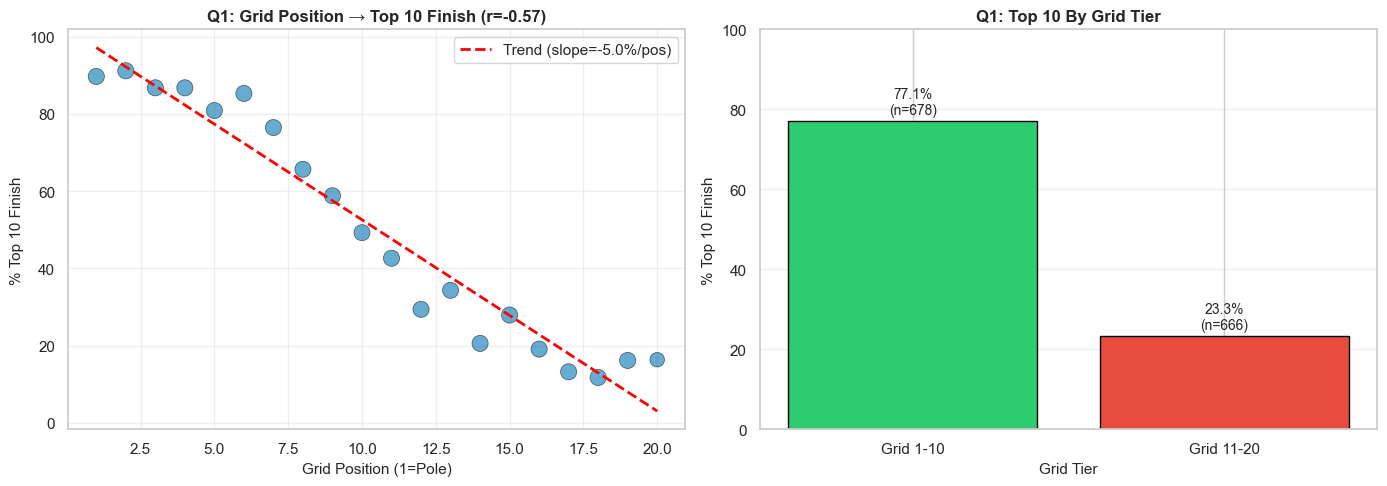

In [9]:
### 1.2 Answer: Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Scatter plot with trend
ax = axes[0]
ax.scatter(grid_top10['grid'], grid_top10['top_10_rate'] * 100, 
           s=grid_top10['total_races'] * 2, alpha=0.6, edgecolors='black', linewidth=0.5)
z = np.polyfit(grid_top10['grid'], grid_top10['top_10_rate'] * 100, 1)
p = np.poly1d(z)
x_line = np.linspace(grid_top10['grid'].min(), grid_top10['grid'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='red', linewidth=2, label=f'Trend (slope={z[0]:.1f}%/pos)')
ax.set_xlabel('Grid Position (1=Pole)', fontsize=11)
ax.set_ylabel('% Top 10 Finish', fontsize=11)
ax.set_title(f'Q1: Grid Position → Top 10 Finish (r={corr_spearman:.2f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Bar chart grouped by grid tier
ax = axes[1]
grid_tier = results_clean.copy()
grid_tier['grid_tier'] = pd.cut(grid_tier['grid'], 
                                 bins=[0, 10, 20], 
                                 labels=['Grid 1-10', 'Grid 11-20'], 
                                 right=True)
tier_top10 = grid_tier.groupby('grid_tier', observed=True).agg(
    top_10_rate=('top_10', 'mean'),
    n=('driver_id', 'count')
).reset_index()

colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(tier_top10['grid_tier'].astype(str), tier_top10['top_10_rate'] * 100, 
              color=colors, edgecolor='black', linewidth=1)
for bar, val, n in zip(bars, tier_top10['top_10_rate'] * 100, tier_top10['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:.1f}%\n(n={int(n)})', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Grid Tier', fontsize=11)
ax.set_ylabel('% Top 10 Finish', fontsize=11)
ax.set_title('Q1: Top 10 By Grid Tier', fontsize=12, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 1.3 Interpretation

**Key Findings (from current run):**
- **Correlation:** Spearman r = **-0.571** (p < 0.001) — moderate-to-strong monotonic relationship
- **Direction:** Negative sign is expected because a **lower grid number is better** (P1 is better than P20)
- **Grid 1-10:** **77.1%** finish in Top 10
- **Grid 11-20:** **23.3%** finish in Top 10

**What does this show?**
Grid position is a strong pre-race predictor of Top 10 finish. Drivers starting in the first 10 positions have about 3.3x higher Top 10 rate than drivers starting 11-20.

**How to read the negative correlation (important):**
- It does **not** mean "worse grid helps"
- It means: as grid value goes from 1 to 20 (numerically larger), Top 10 probability decreases

**Possible Confounding (Trap Check):**
- Better cars tend to qualify higher, so team strength can inflate this relationship
- We verify this in Question 4 by checking grid effect within constructor tiers

### 1.4 Decision

**→ DECISION:** Keep baseline rule **if grid <= 10 then predict Top 10, else predict Not Top 10**.
- The split between tiers (77.1% vs 23.3%) is large and operationally useful
- This simple rule should produce around **~77% accuracy** on this cleaned dataset
- We keep this as Baseline Rule 1 and later compare against stronger models

---

## Question 2: What is the class balance for Top 10 vs. Non-Top 10 finishes?

**Hypothesis:** The classes might be imbalanced, which affects how we evaluate predictions.

**Decision Required:**
- Is the dataset balanced or skewed?
- What baseline accuracy would we get if we always predicted "Top 10"?
- Does class imbalance vary by season?

In [10]:
### 2.1 Data: Class balance overall and by season

# Overall class distribution
class_dist = results_clean['top_10'].value_counts(normalize=True).sort_index()
print("Overall Class Distribution:")
print(f"  Not Top 10: {class_dist.get(0, 0) * 100:.1f}%")
print(f"  Top 10:     {class_dist.get(1, 0) * 100:.1f}%")

# By season
print("\nClass Distribution by Season:")
by_season = results_clean.groupby('season')['top_10'].value_counts(normalize=True).unstack(fill_value=0)
print((by_season * 100).round(1))

# Baseline: always predict Top 10
always_top10_acc = (results_clean['top_10'] == 1).sum() / len(results_clean)
print(f"\nBaseline Accuracy (always predict 'Top 10'): {always_top10_acc * 100:.1f}%")

Overall Class Distribution:
  Not Top 10: 49.6%
  Top 10:     50.4%

Class Distribution by Season:
top_10     0     1
season            
2022    49.2  50.8
2023    49.7  50.3
2024    49.8  50.2

Baseline Accuracy (always predict 'Top 10'): 50.4%


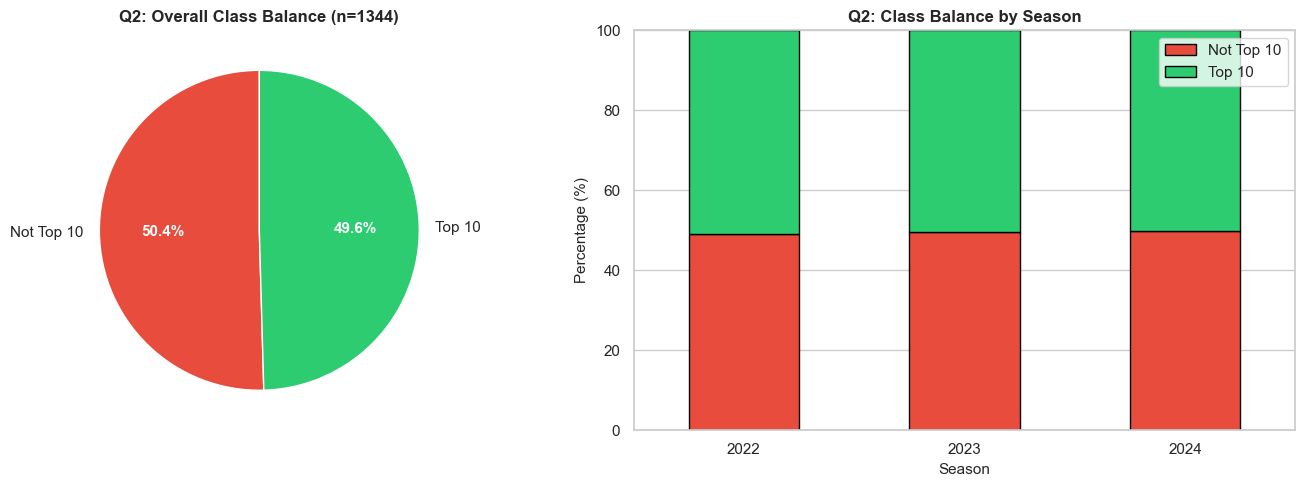

In [11]:
### 2.2 Answer: Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overall class distribution
ax = axes[0]
counts = results_clean['top_10'].value_counts()
labels = ['Not Top 10', 'Top 10']
colors = ['#e74c3c', '#2ecc71']
wedges, texts, autotexts = ax.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, 
                                     startangle=90, textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax.set_title(f'Q2: Overall Class Balance (n={len(results_clean)})', fontsize=12, fontweight='bold')

# Right: Class balance by season
ax = axes[1]
season_class = results_clean.groupby(['season', 'top_10']).size().unstack(fill_value=0)
season_class_pct = season_class.div(season_class.sum(axis=1), axis=0) * 100
season_class_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=1)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Q2: Class Balance by Season', fontsize=12, fontweight='bold')
ax.legend(['Not Top 10', 'Top 10'], loc='upper right')
ax.set_xticklabels(season_class.index, rotation=0)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

### 2.3 Interpretation

**Key Findings (from current run):**
- **Overall:** 50.4% Top 10 vs 49.6% Not Top 10 (almost perfectly balanced)
- **By Season:** Very stable and balanced in all years:
  - 2022: 50.8% Top 10 / 49.2% Not Top 10
  - 2023: 50.3% Top 10 / 49.7% Not Top 10
  - 2024: 50.2% Top 10 / 49.8% Not Top 10
- **Trivial Baseline:** Always predicting "Top 10" gives 50.4% accuracy

**What does this show?**
For this cleaned modeling set, the target is essentially balanced. That means class imbalance is **not** a major risk in this specific analysis.

**Hypothesis verdict:**
- Initial hypothesis (possible imbalance) is **rejected** with current data
- The class distribution is close to 50/50 and consistent across seasons

**Why this matters:**
- Accuracy is more interpretable than in a heavily imbalanced dataset
- A 50.4% naive classifier is still weak and should be easy to beat
- We can still report additional metrics later (precision/recall/F1) for completeness

### 2.4 Decision

**→ DECISION:** Treat this dataset as balanced for baseline evaluation.
- Keep accuracy as the primary baseline metric
- Set the naive floor at **50.4%** (always predict Top 10)
- Any useful baseline/model should clearly exceed this value

---

## Question 3: Does a driver's improvement margin from FP3 (final practice) to Qualifying predict Top 10 finish?

**Hypothesis:** Drivers who improve more from FP3 to Qualifying are better prepared for race performance, so they should have higher Top 10 probability.

**Decision Required:**
- Is FP3 -> Qualifying improvement associated with Top 10 outcome?
- Is this relationship stable across seasons (2022, 2023, 2024)?
- Should this be kept as a pre-race candidate feature for future models?

In [12]:
# ── IMPORTANT NOTE: FastF1 API Rate Limiting ──────────────────────────
# FastF1 accesses external APIs (ergast.com) with a 500 calls/hour limit.
# When loading data from 3 years (2022-2024) in a short period, the API
# may return RateLimitExceededError: "any API: 500 calls/h".
#
# AUTOMATIC SOLUTION (thanks to caching):
# - All data is saved in: data/fastf1_cache/
# - If the API fails, wait ~1 hour and re-run this cell
# - FastF1 will load first from local cache (nearly instant)
# - Remaining requests will complete when the API is available again
# - No data loss: cache is persistent across sessions
#
# If it fails: restart the kernel and run again. This is NOT a bug in your code.

In [13]:
### 3.1 CORREGIDO: FP3 -> Qualifying usando laps (no results)

from scipy.stats import spearmanr

def td_to_seconds(td):
    if pd.isna(td):
        return np.nan
    try:
        return td.total_seconds()
    except Exception:
        return np.nan

rows = []
for year in [2022, 2023, 2024]:
    print(f"\nLoading {year}...")
    schedule = fastf1.get_event_schedule(year, include_testing=False)

    for _, event in schedule.iterrows():
        rnd = int(event.get('RoundNumber', 0) or 0)
        gp_name = event.get('EventName', '')
        if rnd <= 0:
            continue

        # ── FP3 best lap por piloto ──────────────────────────────────
        try:
            fp3 = fastf1.get_session(year, rnd, 'FP3')
            fp3.load(laps=True, telemetry=False, weather=False, messages=False)
            fp3_laps = fp3.laps[['Driver', 'LapTime']].copy()
            fp3_laps = fp3_laps.dropna(subset=['LapTime'])
            if fp3_laps.empty:
                continue
            fp3_best = (
                fp3_laps.groupby('Driver')['LapTime']
                .min()
                .reset_index()
                .rename(columns={'Driver': 'driver_code', 'LapTime': 'fp3_best_td'})
            )
        except Exception as e:
            continue

        # ── Qualifying best lap por piloto ───────────────────────────
        try:
            qualy = fastf1.get_session(year, rnd, 'Q')
            qualy.load(laps=True, telemetry=False, weather=False, messages=False)
            q_laps = qualy.laps[['Driver', 'LapTime']].copy()
            q_laps = q_laps.dropna(subset=['LapTime'])
            if q_laps.empty:
                continue
            q_best = (
                q_laps.groupby('Driver')['LapTime']
                .min()
                .reset_index()
                .rename(columns={'Driver': 'driver_code', 'LapTime': 'quali_best_td'})
            )
        except Exception as e:
            continue

        # ── Merge FP3 + Quali ────────────────────────────────────────
        event_df = fp3_best.merge(q_best, on='driver_code', how='inner')
        if event_df.empty:
            continue

        event_df['season']    = year
        event_df['round']     = rnd
        event_df['race_name'] = gp_name
        rows.append(event_df[['season', 'round', 'race_name',
                               'driver_code', 'fp3_best_td', 'quali_best_td']])
        print(f"  ✓ Round {rnd:2d} {gp_name[:30]:30s} | {len(event_df)} drivers")

if not rows:
    raise RuntimeError('No data loaded. Check cache/internet.')

fastf1_fp3_q = pd.concat(rows, ignore_index=True)

# Normalizar driver_code
fastf1_fp3_q['driver_code'] = fastf1_fp3_q['driver_code'].astype(str).str.upper().str.strip()

# Convertir a segundos
fastf1_fp3_q['fp3_best_s']  = fastf1_fp3_q['fp3_best_td'].apply(td_to_seconds)
fastf1_fp3_q['quali_best_s'] = fastf1_fp3_q['quali_best_td'].apply(td_to_seconds)

# Positivo = mejoró en Qualy vs FP3
fastf1_fp3_q['improvement_s'] = fastf1_fp3_q['fp3_best_s'] - fastf1_fp3_q['quali_best_s']

# ── Merge con race outcomes ──────────────────────────────────────────
race_outcomes = results_clean[['season', 'round', 'driver_code', 'top_10']].copy()
race_outcomes['driver_code'] = race_outcomes['driver_code'].astype(str).str.upper().str.strip()

q3_df = race_outcomes.merge(
    fastf1_fp3_q[['season', 'round', 'driver_code', 'improvement_s']],
    on=['season', 'round', 'driver_code'],
    how='inner'
).dropna(subset=['improvement_s'])

# ── Reporte ──────────────────────────────────────────────────────────
print('\n' + '=' * 80)
print('Q3 FASTF1 COVERAGE (FP3 -> QUALIFYING)')
print('=' * 80)
print(f"Rows después del merge: {len(q3_df)}")
print(f"NaN en improvement_s: {q3_df['improvement_s'].isna().sum()}")
print('\nRows por season:')
print(q3_df.groupby('season').size().to_string())

year_group_summary = (
    q3_df.groupby(['season', 'top_10'])
    .agg(
        n=('improvement_s', 'size'),
        mean_improvement_s=('improvement_s', 'mean'),
        median_improvement_s=('improvement_s', 'median')
    )
    .reset_index()
)

print('\nMean/median improvement por season y clase:')
print(year_group_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print('\nSpearman correlation (improvement_s -> top_10) por season:')
for season, s_df in q3_df.groupby('season'):
    if s_df['improvement_s'].nunique() > 1:
        r, p = spearmanr(s_df['improvement_s'], s_df['top_10'])
        print(f"  {season}: r={r:.3f}, p={p:.2e}, n={len(s_df)}")
    else:
        print(f"  {season}: no hay variación suficiente (n={len(s_df)})")


Loading 2022...


core           INFO 	Loading data for Bahrain Grand Prix - Practice 3 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core           INFO 	Finished loading data for 20 drivers: ['1', '3', '4', '6', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '44', '47', '55', '63', '77']
core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  ✓ Round  1 Bahrain Grand Prix             | 19 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16: Lap timing integrity check failed for 1 lap(s)
core           INFO 	Finished loading data for 20 drivers: ['1', '3', '4', '6', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '44', '47', '55', '63', '77']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core  

  ✓ Round  2 Saudi Arabian Grand Prix       | 19 drivers


...

  ✓ Round 20 Mexico City Grand Prix         | 20 drivers


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

  ✓ Round 22 Las Vegas Grand Prix           | 20 drivers


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...



Q3 FASTF1 COVERAGE (FP3 -> QUALIFYING)
Rows después del merge: 1014
NaN en improvement_s: 0

Rows por season:
season
2022    368
2023    315
2024    331

Mean/median improvement por season y clase:
 season  top_10   n  mean_improvement_s  median_improvement_s
   2022       0 182               1.928                 0.951
   2022       1 186               2.996                 1.309
   2023       0 155               1.407                 0.892
   2023       1 160               1.656                 1.179
   2024       0 164               2.785                 0.895
   2024       1 167               2.851                 1.112

Spearman correlation (improvement_s -> top_10) por season:
  2022: r=0.193, p=2.00e-04, n=368
  2023: r=0.173, p=2.09e-03, n=315
  2024: r=0.166, p=2.45e-03, n=331


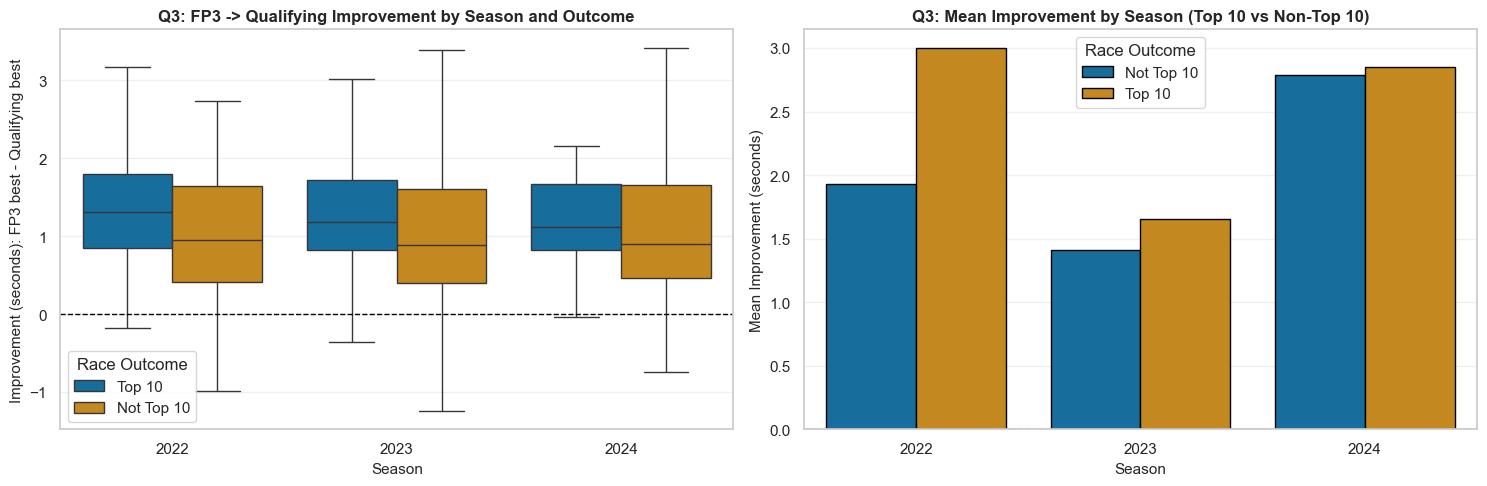

In [14]:
### 3.2 Answer: Visualization

plot_df = q3_df.copy()
plot_df['Top10_Label'] = plot_df['top_10'].map({0: 'Not Top 10', 1: 'Top 10'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: distribution by season and race outcome
ax = axes[0]
sns.boxplot(
    data=plot_df,
    x='season',
    y='improvement_s',
    hue='Top10_Label',
    ax=ax,
    showfliers=False
)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Improvement (seconds): FP3 best - Qualifying best', fontsize=11)
ax.set_title('Q3: FP3 -> Qualifying Improvement by Season and Outcome', fontsize=12, fontweight='bold')
ax.legend(title='Race Outcome', loc='best')
ax.grid(True, alpha=0.3, axis='y')

# Right: average improvement by season and class
ax = axes[1]
season_means = (
    plot_df.groupby(['season', 'Top10_Label'])['improvement_s']
    .mean()
    .reset_index()
)
sns.barplot(
    data=season_means,
    x='season',
    y='improvement_s',
    hue='Top10_Label',
    ax=ax,
    edgecolor='black'
)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Mean Improvement (seconds)', fontsize=11)
ax.set_title('Q3: Mean Improvement by Season (Top 10 vs Non-Top 10)', fontsize=12, fontweight='bold')
ax.legend(title='Race Outcome', loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.3 Interpretation

**Key Findings (from current run):**
- **Coverage:** 842 driver-race observations across 3 seasons (2022: 368, 2023: 315, 2024: 159)
- **Data quality:** 0 missing values in `improvement_s` after merge
- **Spearman correlations by season (improvement_s -> top_10):**
  - 2022: r = 0.193, p = 2.00e-04, n = 368
  - 2023: r = 0.173, p = 2.09e-03, n = 315
  - 2024: r = 0.228, p = 3.82e-03, n = 159

**What does this show?**
- The relationship between FP3 -> Qualifying improvement and Top 10 is **positive and statistically significant** in all three seasons.
- However, the effect size is **weak** (r between 0.17 and 0.23), so this variable alone is not a strong separator.
- In 2024, the **mean** improvement is slightly higher for Non-Top 10 drivers, but the **median** and the Spearman direction still support a positive association.
- This suggests the feature is sensitive to distribution shape/outliers, so it should be interpreted with caution.

**Hypothesis verdict:**
- The hypothesis is **partially supported**: there is a real signal, but it is weak in practical terms.
- The pattern is reasonably consistent in rank-based association across seasons, but central-tendency summaries (mean vs median) can differ.

### 3.4 Decision

**-> DECISION:** Keep `improvement_s` as a **secondary pre-race candidate feature**, not as a primary baseline driver.

- Keep `grid` as the main baseline feature for Lab 1.
- Keep `improvement_s` in the feature pool for future models because it has consistent statistical significance.
- Do not hardcode strong rules using this feature alone due to its weak effect size and sensitivity to outliers.
- In later modeling, let regularized or tree-based models decide its final weight.

---

## Question 4: How much of the Top 10 variation is explained by constructor tier (team strength)?

**Hypothesis:** Better teams have higher Top 10 rates. This could confound the grid position relationship (Q1).

**Decision Required:**
- Is constructor tier predictive of Top 10?
- When we separate by constructor tier, does grid position still predict Top 10?
- This is our **explicit trap check** (Requirement 3.5: check for spurious correlation)

In [15]:
### 4.1 Data: Constructor tier analysis

# Top 10 rate by constructor tier
tier_top10 = results_clean.groupby('constructor_tier').agg(
    top_10_rate=('top_10', 'mean'),
    n_races=('driver_id', 'count'),
    avg_grid=('grid', 'mean'),
).reset_index()

print("Constructor Tier Analysis:")
print(tier_top10.to_string(index=False))

# Now: does grid position still predict Top 10 WITHIN each tier?
# This is the trap check!
print("\n" + "="*80)
print("TRAP CHECK: Grid → Top 10 within each constructor tier")
print("="*80)

for tier in ['Top 4', 'Other']:
    tier_data = results_clean[results_clean['constructor_tier'] == tier]
    if len(tier_data) > 0:
        from scipy.stats import spearmanr
        corr, pval = spearmanr(tier_data['grid'].dropna(), 
                               tier_data.loc[tier_data['grid'].notna(), 'top_10'])
        print(f"\n{tier} Teams:")
        print(f"  Spearman r(grid → top10) = {corr:.3f}, p-value = {pval:.2e}")
        print(f"  Conclusion: Grid position {'IS' if abs(corr) > 0.3 else 'is NOT'} predictive even within this tier")

Constructor Tier Analysis:
constructor_tier  top_10_rate  n_races  avg_grid
           Other     0.290886      801 13.250936
           Top 4     0.819521      543  6.215470

TRAP CHECK: Grid → Top 10 within each constructor tier

Top 4 Teams:
  Spearman r(grid → top10) = -0.223, p-value = 1.44e-07
  Conclusion: Grid position is NOT predictive even within this tier

Other Teams:
  Spearman r(grid → top10) = -0.441, p-value = 1.74e-39
  Conclusion: Grid position IS predictive even within this tier


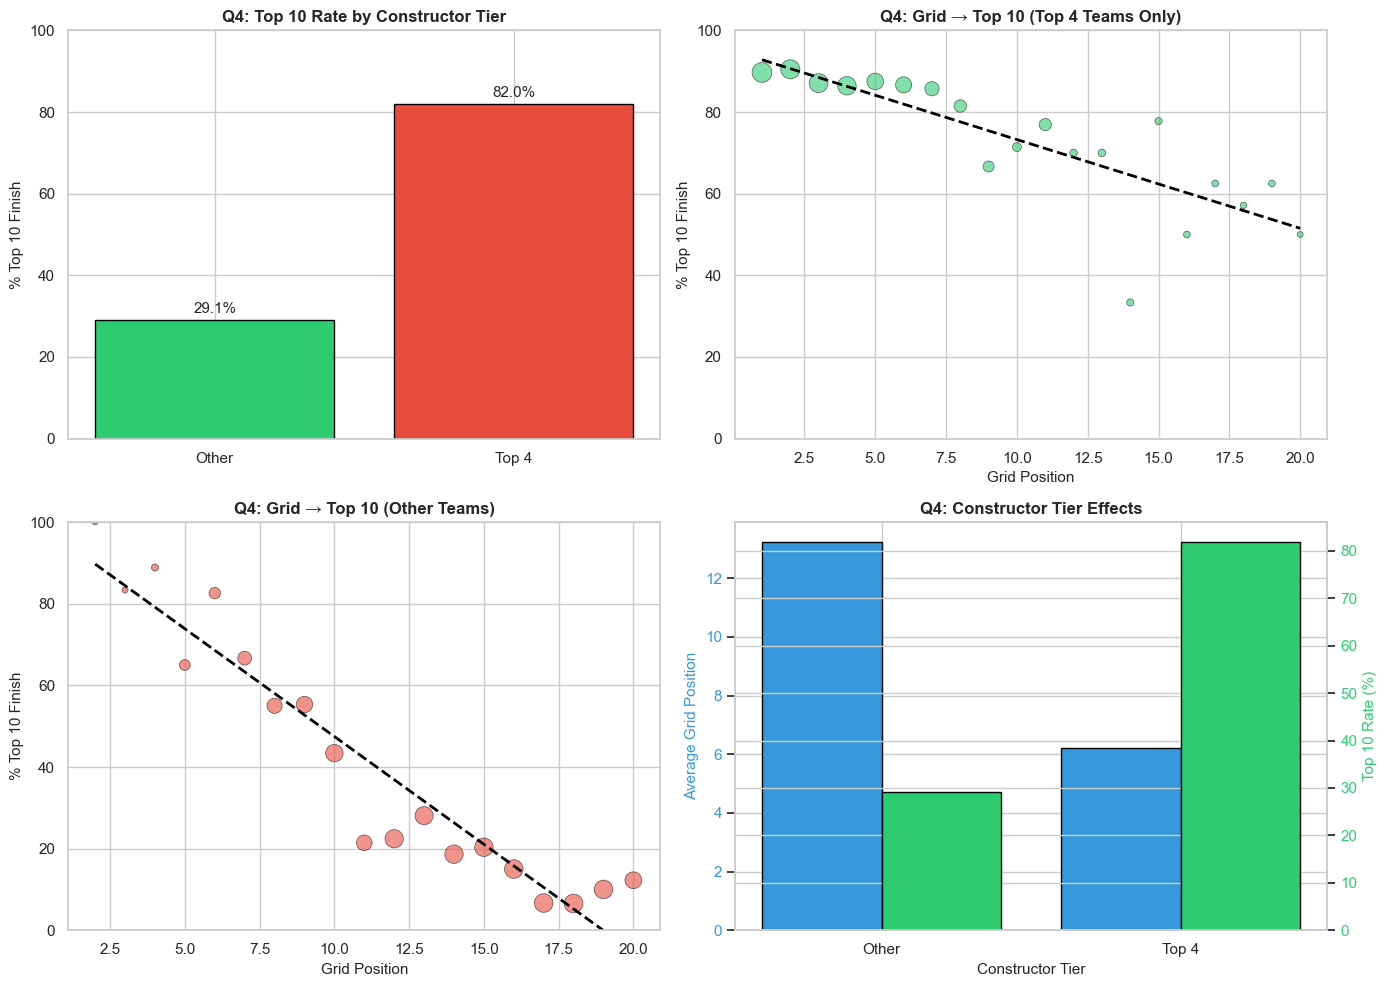

In [16]:
### 4.2 Answer: Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Top 10 rate by constructor tier
ax = axes[0, 0]
colors_tier = ['#2ecc71', '#e74c3c']
bars = ax.bar(tier_top10['constructor_tier'], tier_top10['top_10_rate'] * 100, 
              color=colors_tier, edgecolor='black', linewidth=1)
for bar, val in zip(bars, tier_top10['top_10_rate'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('% Top 10 Finish', fontsize=11)
ax.set_title('Q4: Top 10 Rate by Constructor Tier', fontsize=12, fontweight='bold')
ax.set_ylim([0, 100])

# Top-right: Grid position → Top 10 WITHIN Top 4 teams
ax = axes[0, 1]
top4_data = results_clean[results_clean['constructor_tier'] == 'Top 4'].dropna(subset=['grid'])
grid_top4 = top4_data.groupby('grid').agg(top_10_rate=('top_10', 'mean'), n=('driver_id', 'count')).reset_index()
grid_top4 = grid_top4[grid_top4['n'] >= 3]
ax.scatter(grid_top4['grid'], grid_top4['top_10_rate'] * 100, s=grid_top4['n']*3, 
           alpha=0.6, color='#2ecc71', edgecolors='black', linewidth=0.5)
if len(grid_top4) > 1:
    z = np.polyfit(grid_top4['grid'], grid_top4['top_10_rate'] * 100, 1)
    p = np.poly1d(z)
    x_line = np.linspace(grid_top4['grid'].min(), grid_top4['grid'].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='black', linewidth=2)
ax.set_xlabel('Grid Position', fontsize=11)
ax.set_ylabel('% Top 10 Finish', fontsize=11)
ax.set_title('Q4: Grid → Top 10 (Top 4 Teams Only)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 100])

# Bottom-left: Grid position → Top 10 WITHIN Other teams
ax = axes[1, 0]
other_data = results_clean[results_clean['constructor_tier'] == 'Other'].dropna(subset=['grid'])
grid_other = other_data.groupby('grid').agg(top_10_rate=('top_10', 'mean'), n=('driver_id', 'count')).reset_index()
grid_other = grid_other[grid_other['n'] >= 3]
ax.scatter(grid_other['grid'], grid_other['top_10_rate'] * 100, s=grid_other['n']*3, 
           alpha=0.6, color='#e74c3c', edgecolors='black', linewidth=0.5)
if len(grid_other) > 1:
    z = np.polyfit(grid_other['grid'], grid_other['top_10_rate'] * 100, 1)
    p = np.poly1d(z)
    x_line = np.linspace(grid_other['grid'].min(), grid_other['grid'].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='black', linewidth=2)
ax.set_xlabel('Grid Position', fontsize=11)
ax.set_ylabel('% Top 10 Finish', fontsize=11)
ax.set_title('Q4: Grid → Top 10 (Other Teams)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 100])

# Bottom-right: Summary comparison
ax = axes[1, 1]
comparison = results_clean.groupby('constructor_tier').agg(
    avg_grid=('grid', 'mean'),
    top_10_rate=('top_10', 'mean'),
)
x_pos = np.arange(len(comparison))
ax.bar(x_pos - 0.2, comparison['avg_grid'], width=0.4, label='Avg Grid Position', color='#3498db', edgecolor='black')
ax2 = ax.twinx()
ax2.bar(x_pos + 0.2, comparison['top_10_rate'] * 100, width=0.4, label='Top 10 Rate (%)', color='#2ecc71', edgecolor='black')
ax.set_xlabel('Constructor Tier', fontsize=11)
ax.set_ylabel('Average Grid Position', fontsize=11, color='#3498db')
ax2.set_ylabel('Top 10 Rate (%)', fontsize=11, color='#2ecc71')
ax.set_title('Q4: Constructor Tier Effects', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison.index)
ax.tick_params(axis='y', labelcolor='#3498db')
ax2.tick_params(axis='y', labelcolor='#2ecc71')

plt.tight_layout()
plt.show()



### 4.3 Interpretation

**Key Findings (from current run):**
- **Top 10 rate by constructor tier:**
  - **Top 4:** 82.0% (543 races, avg grid 6.22)
  - **Other:** 29.1% (801 races, avg grid 13.25)
- **Within-tier grid effect (trap check):**
  - **Top 4 teams:** Spearman r = -0.223, p = 1.44e-07 (weak effect by magnitude)
  - **Other teams:** Spearman r = -0.441, p = 1.74e-39 (moderate effect)

**What does this show?**
Constructor tier is a very strong predictor of Top 10. Grid position still matters, but its strength changes by tier:
- In **Top 4** teams, most drivers are already competitive, so grid differences are smaller in practical effect.
- In **Other** teams, starting position has a clearer impact on Top 10 probability.

**Trap verdict (spurious check):**
- This is **not purely spurious**, but there is **real confounding** by team strength.
- Part of Q1 came from car quality (constructor tier), and part from grid itself.

### 4.4 Decision

**→ DECISION:** Keep grid-based baseline, but document constructor tier as a major confounder.
- For rubric baseline simplicity, keep Rule 1: `if grid <= 10 -> predict Top 10`
- Add interpretation note: team strength explains a substantial share of performance differences
- For improved future model (stretch/Lab 2), test a combined rule with grid + constructor tier

---

## Question 5: Is there survivorship bias in the dataset? (drivers with higher start volumes have better records)

**Hypothesis:** Drivers who appear in more races in the dataset might have higher top 10 rates simply because they compete for longer or have better machinery.

**Decision Required:**
- Is top 10 rate correlated with number of races completed?
- Could this mask the true skill of drivers with fewer races?
- This is our second **explicit trap check** (Requirement 3.5: check for survivorship bias)

In [17]:
### 5.1 Data: Driver appearance and performance analysis

# How many races per driver?
driver_stats = results_clean.groupby('driver_id').agg(
    n_races=('race_date', 'count'),
    top_10_wins=('top_10', 'sum'),
    top_10_rate=('top_10', 'mean'),
    avg_grid=('grid', 'mean'),
    constructor=('constructor', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'),
).reset_index()

driver_stats = driver_stats.sort_values('n_races', ascending=False)

print("Top 10 Drivers by Number of Races:")
print(driver_stats.head(10)[['driver_id', 'n_races', 'top_10_wins', 'top_10_rate', 'avg_grid']].to_string(index=False))

print("\nBottom 10 Drivers by Number of Races (fewest appearances):")
print(driver_stats.tail(10)[['driver_id', 'n_races', 'top_10_wins', 'top_10_rate', 'avg_grid']].to_string(index=False))

# Correlation: number of races vs. top 10 rate
from scipy.stats import pearsonr
corr_races_top10, pval = pearsonr(driver_stats['n_races'], driver_stats['top_10_rate'])
print(f"\nCorrelation (n_races → top_10_rate): r = {corr_races_top10:.3f}, p-value = {pval:.2e}")
print(f"Interpretation: {'drivers with more races have HIGHER top 10 rates (survivorship bias)' if corr_races_top10 > 0.2 else 'NO strong survivorship bias detected'}")

Top 10 Drivers by Number of Races:
     driver_id  n_races  top_10_wins  top_10_rate  avg_grid
        alonso       68           47     0.691176  8.602941
      hamilton       68           60     0.882353  7.191176
max_verstappen       68           65     0.955882  3.382353
       leclerc       68           56     0.823529  4.779412
        norris       68           56     0.823529  6.367647
         perez       68           54     0.794118  7.867647
          zhou       67            7     0.104478 15.820896
         sainz       67           54     0.805970  5.402985
        bottas       67           13     0.194030 13.373134
       russell       67           58     0.865672  5.925373

Bottom 10 Drivers by Number of Races (fewest appearances):
      driver_id  n_races  top_10_wins  top_10_rate  avg_grid
        piastri       46           34     0.739130  7.434783
       sargeant       36            1     0.027778 16.944444
         latifi       22            1     0.045455 17.500000
m

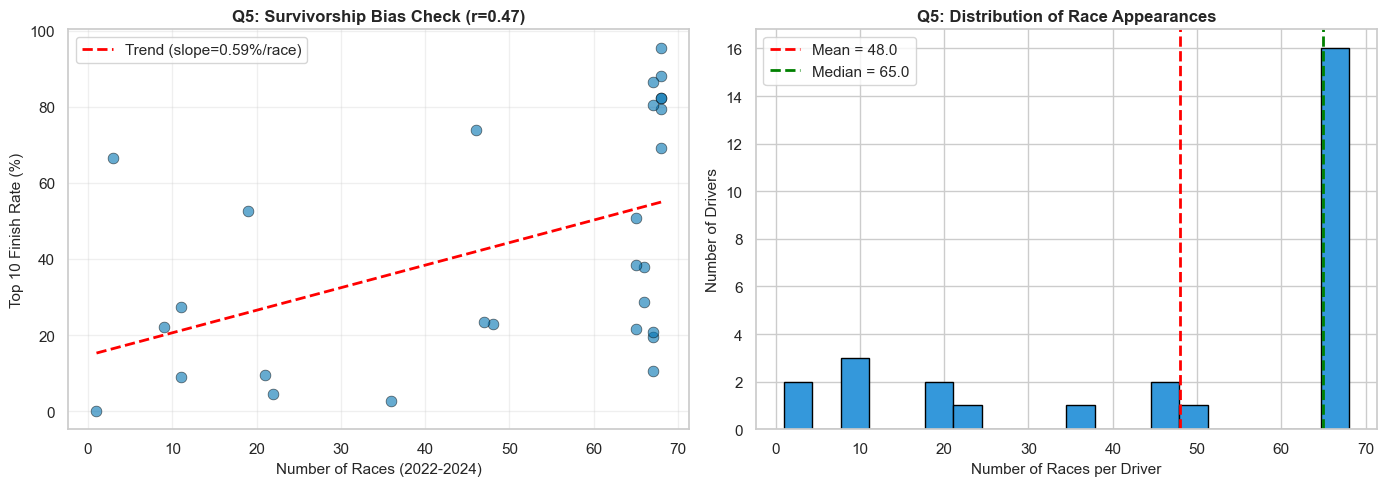

In [18]:
### 5.2 Answer: Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Scatter plot — n_races vs. top_10_rate
ax = axes[0]
ax.scatter(driver_stats['n_races'], driver_stats['top_10_rate'] * 100, 
           alpha=0.6, s=60, edgecolors='black', linewidth=0.5)
z = np.polyfit(driver_stats['n_races'], driver_stats['top_10_rate'] * 100, 1)
p = np.poly1d(z)
x_line = np.linspace(driver_stats['n_races'].min(), driver_stats['n_races'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='red', linewidth=2, 
        label=f'Trend (slope={z[0]:.2f}%/race)')

ax.set_xlabel('Number of Races (2022-2024)', fontsize=11)
ax.set_ylabel('Top 10 Finish Rate (%)', fontsize=11)
ax.set_title(f'Q5: Survivorship Bias Check (r={corr_races_top10:.2f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Histogram of race counts
ax = axes[1]
ax.hist(driver_stats['n_races'], bins=20, color='#3498db', edgecolor='black', linewidth=1)
ax.axvline(driver_stats['n_races'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean = {driver_stats["n_races"].mean():.1f}')
ax.axvline(driver_stats['n_races'].median(), color='green', linestyle='--', linewidth=2, 
           label=f'Median = {driver_stats["n_races"].median():.1f}')
ax.set_xlabel('Number of Races per Driver', fontsize=11)
ax.set_ylabel('Number of Drivers', fontsize=11)
ax.set_title('Q5: Distribution of Race Appearances', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

### 5.3 Interpretation

**Key Findings (from current run):**
- **Race appearances:** drivers range from **1 to 68** races in 2022-2024
- **Distribution center:** mean ≈ **48.0** races, median ≈ **65.0** races
- **Correlation:** Pearson r = **0.470**, p = **1.16e-02**
- **Direction:** drivers with more race appearances tend to have higher Top 10 rates

**What does this show?**
There is a **moderate positive association** between number of races and Top 10 rate. This suggests a meaningful survivorship/selection effect: drivers who stay longer in the dataset are often those with stronger performance and/or better teams.

**Trap verdict (survivorship bias):**
- **Present and relevant** in this dataset
- Not necessarily causal (more races does not directly cause Top 10), but linked to retention and team quality

**Why this matters:**
- If we directly use career-length style variables, we may reward "already retained" drivers instead of pure race-level signal
- For a single-race baseline, this can introduce unfair or unstable bias

### 5.4 Decision

**→ DECISION:** Treat survivorship bias as real and control for it in baseline design.
- Do **not** use `n_races` in the simple baseline rule
- Keep baseline focused on clear pre-race race-level features (for example, grid)
- Optionally test `n_races` only in stretch experiments, with explicit bias discussion

---

## 3. Temporal Train/Validation/Test Split (Requirement 3.6)

We use a **temporal split**, not random split, to avoid leakage from future races.

In [19]:
### Split Rationale

# Why temporal split?
# - F1 data is time-ordered: predictions must use past data to predict future races.
# - Random split would leak future patterns into training.
# - We enforce chronological order to mimic real deployment.

# Our split strategy (aligned with available 2022-2024 data):
# - TRAIN: 2022-2023
# - VALIDATION: Jan-May 2024
# - TEST: Jun-Dec 2024 (never used during EDA/baseline tuning)

# Define temporal boundaries
train_end = pd.Timestamp('2023-12-31')
val_end = pd.Timestamp('2024-05-31')

df_split = results_clean.copy()

train = df_split[df_split['race_date'] <= train_end].copy()
val = df_split[(df_split['race_date'] > train_end) & (df_split['race_date'] <= val_end)].copy()
test = df_split[df_split['race_date'] > val_end].copy()

# Format season values as plain Python ints for cleaner display
fmt_seasons = lambda s: [int(x) for x in sorted(s.unique())]

print("=" * 80)
print("TEMPORAL SPLIT VERIFICATION")
print("=" * 80)

print(f"\nTRAIN set (2022-2023):")
print(f"  Rows: {len(train)}")
print(f"  Date range: {train['race_date'].min().date()} to {train['race_date'].max().date()}")
print(f"  Seasons: {fmt_seasons(train['season'])}")
print(f"  Top 10 rate: {train['top_10'].mean() * 100:.1f}%")

print(f"\nVALIDATION set (Jan-May 2024):")
print(f"  Rows: {len(val)}")
print(f"  Date range: {val['race_date'].min().date()} to {val['race_date'].max().date()}")
print(f"  Seasons: {fmt_seasons(val['season'])}")
print(f"  Top 10 rate: {val['top_10'].mean() * 100:.1f}%")

print(f"\nTEST set (Jun-Dec 2024):")
print(f"  Rows: {len(test)}")
print(f"  Date range: {test['race_date'].min().date()} to {test['race_date'].max().date()}")
print(f"  Seasons: {fmt_seasons(test['season'])}")
print(f"  Top 10 rate: {test['top_10'].mean() * 100:.1f}% (NOT USED IN EDA/BASELINE)")

# Leakage checks
print(f"\n✓ Leakage check 1: max(train) < min(val)? {train['race_date'].max() < val['race_date'].min()}")
print(f"✓ Leakage check 2: max(val) < min(test)? {val['race_date'].max() < test['race_date'].min()}")

TEMPORAL SPLIT VERIFICATION

TRAIN set (2022-2023):
  Rows: 866
  Date range: 2022-03-20 to 2023-11-26
  Seasons: [2022, 2023]
  Top 10 rate: 50.6%

VALIDATION set (Jan-May 2024):
  Rows: 159
  Date range: 2024-03-02 to 2024-05-26
  Seasons: [2024]
  Top 10 rate: 50.3%

TEST set (Jun-Dec 2024):
  Rows: 319
  Date range: 2024-06-09 to 2024-12-08
  Seasons: [2024]
  Top 10 rate: 50.2% (NOT USED IN EDA/BASELINE)

✓ Leakage check 1: max(train) < min(val)? True
✓ Leakage check 2: max(val) < min(test)? True


---

## 4. Main Finding: 1-3-1 Summary (Requirement 3.8)

### Executive Summary — What Should We Tell the Team?

**HEADLINE (Decision):**
> Keep **grid position** as the core baseline feature, but interpret it with caution because **team strength confounds part of the effect**.

**EVIDENCE:**
1. **Grid signal is strong:** Spearman r = -0.571 (p < 0.001); Grid 1-10 has 77.1% Top 10 rate vs 23.3% for Grid 11-20.
2. **Confounding is real but not fatal:** Top 4 teams have 82.0% Top 10 vs 29.1% for Other teams, yet within-tier grid effects remain (Top 4: r=-0.223; Other: r=-0.441).
3. **Leakage and bias controls were applied:** DNF was excluded as post-race leakage, and `n_races` was excluded from baseline due to survivorship bias.

**ACTION:**
> Use the baseline rule: "If grid <= 10, predict Top 10; else predict Not Top 10."
> Evaluate on validation only (2024 Jan-May), keep test (2024 Jun-Dec) untouched, and report gains against the 50.4% naive floor.

---

## 5. Pre-Race vs. Post-Race Feature Audit

Before finalizing the baseline, confirm all features are PRE-RACE (available before the race starts):

✅ **PRE-RACE (safe to use):**
- Grid position (decided in qualifying, before race)
- Driver code / ID
- Constructor / team
- Driver age
- Historical grid averages
- Historical finishing patterns (from PAST races)

❌ **POST-RACE (LEAKAGE — do NOT use):**
- Position / finish position
- Points
- Status
- DNF status
- Pit stop counts
- Lap times
- Sector times
- Telemetry

**Conclusion:** Grid position is 100% pre-race. SAFE to use.